# Appendix B — Recall-guarded directional accuracy is a coin flip

Reads persisted artifacts only (no model calls, no recomputation):

- `data/naive_directional_eval_openai_gpt-oss-20b.parquet` — v1 sample (2019–2024, n=72)
- `data/naive_directional_eval_ext2026.parquet` — extended stream (2019–2026, n=90; superset of v1)
- `data/norecall_screen/results.json` + `evidence/<model>/evidence.parquet` — the five-model recall screen (§5)
- `data/factor_decision_log_{v1,ext2026}.json` (recall-guarded PIT) and
  `data/factor_nonpit_diagnostic_decision_log_{v1,ext2026}.json` (recall-enabled control) — before/after decision streams (§5)

For each walk-forward rebalance date the recall-guarded gpt-oss-20b was asked for the
next-month direction of world equity from an anonymized, date-free, PIT macro state
(nb13 §S2). This appendix quantifies and charts the headline claim: directional
accuracy is statistically indistinguishable from a coin flip — the expected, correct
result, since the guard removes the memorization channel and the model was never
supposed to forecast.

## 1. Load persisted results

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

REPO = Path.cwd().parent
DATA = REPO / "data"

v1 = pd.read_parquet(DATA / "naive_directional_eval_openai_gpt-oss-20b.parquet")
ext = pd.read_parquet(DATA / "naive_directional_eval_ext2026.parquet")
for df in (v1, ext):
    df["date"] = pd.to_datetime(df["date"])
print("v1:", len(v1), "obs |", v1["date"].min().date(), "->", v1["date"].max().date())
print("ext2026:", len(ext), "obs |", ext["date"].min().date(), "->", ext["date"].max().date())

v1: 72 obs | 2019-01-02 -> 2024-12-02
ext2026: 90 obs | 2019-01-02 -> 2026-06-01


## 2. Accuracy vs coin flip — Wilson intervals and binomial tests

Wilson score interval for the hit-rate proportion; exact two-sided binomial test against
p = 0.5. The always-long base rate (realized up-month share) is reported alongside: a
strategy with genuine skill must beat *both* chance and that naive baseline.

In [2]:
def wilson(k, n, z=1.959963984540054):
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h

rows = []
for name, df in [("v1 (2019-2024)", v1), ("ext2026 (2019-2026)", ext)]:
    n, k = len(df), int(df["correct"].sum())
    lo, hi = wilson(k, n)
    p = stats.binomtest(k, n, 0.5).pvalue
    rows.append({"run": name, "hits": f"{k}/{n}", "accuracy": round(k / n, 3),
                 "wilson_95": f"[{lo:.3f}, {hi:.3f}]", "binom_p_vs_0.5": round(p, 3),
                 "contains_0.5": lo <= 0.5 <= hi,
                 "always_long_base_rate": round((df["realized_direction"] == 1).mean(), 3)})
summary = pd.DataFrame(rows)
summary

,run,hits,accuracy,wilson_95,binom_p_vs_0.5,contains_0.5,always_long_base_rate
0,v1 (2019-2024),28/72,0.389,"[0.285, 0.504]",0.076,True,0.667
1,ext2026 (2019-2026),37/90,0.411,"[0.315, 0.514]",0.113,True,0.667


## 3. Chart — cumulative accuracy inside the chance funnel

Cumulative hit rate of the extended stream as the sample grows, with its Wilson 95%
band. The band never excludes the 0.5 chance line, and the final estimate also sits
below the always-long base rate: no directional alpha, guarded as intended. Bottom
strip: the raw per-rebalance hit/miss sequence behind the curve.

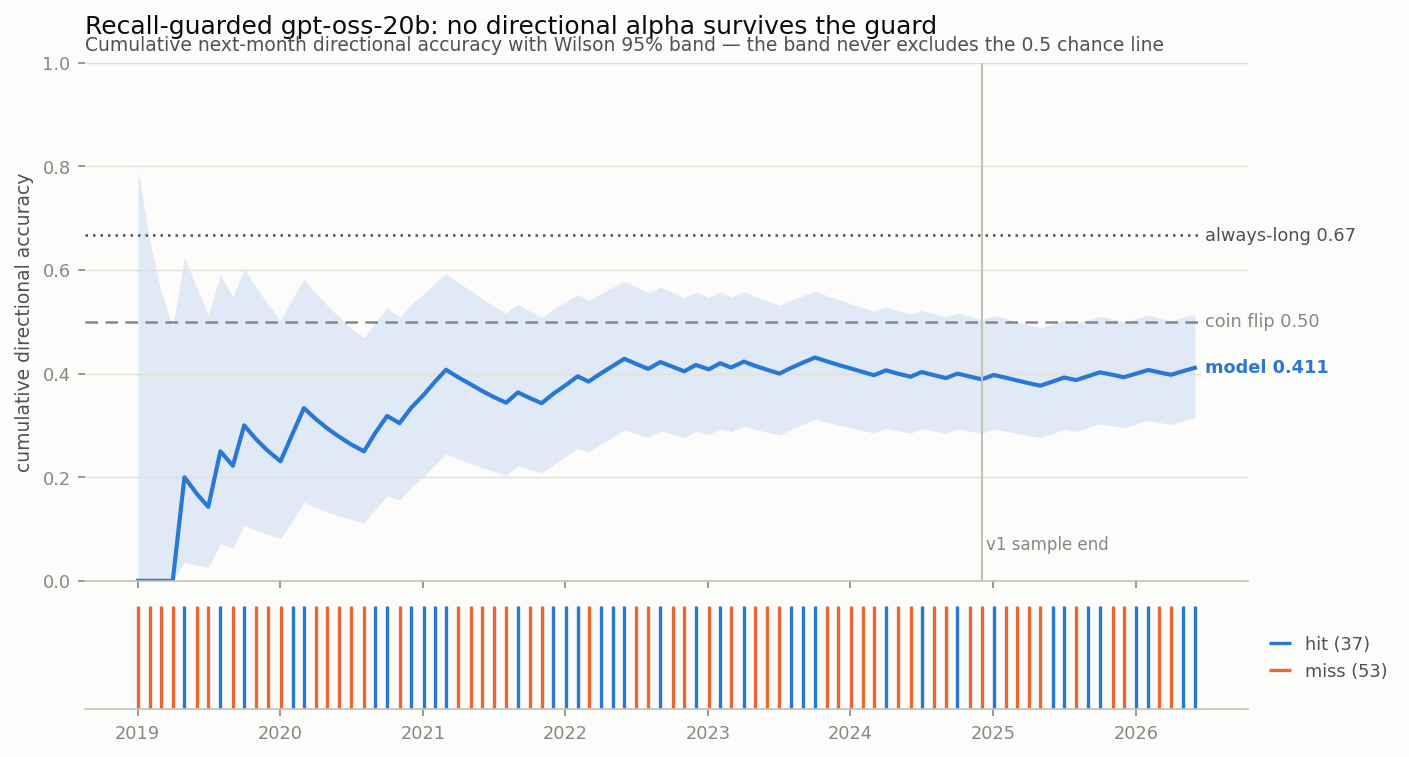

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# palette (dataviz reference, light mode)
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"

d = ext.sort_values("date").reset_index(drop=True)
n_seq = np.arange(1, len(d) + 1)
cum_acc = d["correct"].cumsum() / n_seq
band = np.array([wilson(k, n) for k, n in zip(d["correct"].cumsum(), n_seq)])
base_rate = (d["realized_direction"] == 1).mean()
v1_end = v1["date"].max()

fig, (ax, axs) = plt.subplots(
    2, 1, figsize=(10, 5.6), dpi=150, sharex=True,
    gridspec_kw={"height_ratios": [5, 1], "hspace": 0.08})
fig.patch.set_facecolor(SURFACE)

ax.set_facecolor(SURFACE)
ax.fill_between(d["date"], band[:, 0], band[:, 1], color=BLUE, alpha=0.13, lw=0)
ax.plot(d["date"], cum_acc, color=BLUE, lw=2)
ax.axhline(0.5, color=MUTED, lw=1.2, ls=(0, (5, 3)))
ax.axhline(base_rate, color=INK2, lw=1.2, ls=(0, (1, 2)))
ax.axvline(v1_end, color=BASELINE, lw=1)

mask = dict(facecolor=SURFACE, edgecolor="none", pad=1.5)
x_right = d["date"].iloc[-1] + pd.Timedelta(days=25)
ax.text(x_right, 0.5, "coin flip 0.50", color=MUTED, fontsize=8.5, va="center", bbox=mask)
ax.text(x_right, base_rate, f"always-long {base_rate:.2f}", color=INK2, fontsize=8.5,
        va="center", bbox=mask)
ax.text(x_right, cum_acc.iloc[-1], f"model {cum_acc.iloc[-1]:.3f}",
        color=BLUE, fontsize=8.5, va="center", fontweight="bold", bbox=mask)
ax.text(v1_end + pd.Timedelta(days=12), 0.06, "v1 sample end", color=MUTED, fontsize=8,
        ha="left", transform=ax.get_xaxis_transform(), bbox=mask)

ax.set_ylim(0, 1)
ax.set_ylabel("cumulative directional accuracy", color=INK2, fontsize=9)
ax.grid(axis="y", color=GRID, lw=0.7)
ax.tick_params(colors=MUTED, labelsize=8.5)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)

# hit/miss strip
axs.set_facecolor(SURFACE)
hits, miss = d[d["correct"]], d[~d["correct"]]
axs.vlines(hits["date"], 0, 1, color=BLUE, lw=1.6, label=f"hit ({len(hits)})")
axs.vlines(miss["date"], 0, 1, color=ORANGE, lw=1.6, label=f"miss ({len(miss)})")
axs.set_ylim(0, 1)
axs.set_yticks([])
axs.tick_params(colors=MUTED, labelsize=8.5)
for s in ("top", "right", "left"):
    axs.spines[s].set_visible(False)
axs.spines["bottom"].set_color(BASELINE)
axs.xaxis.set_major_locator(mdates.YearLocator())
axs.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axs.legend(loc="center left", bbox_to_anchor=(1.005, 0.5), frameon=False,
           fontsize=8.5, labelcolor=INK2, handlelength=1.2)

ax.set_title("Recall-guarded gpt-oss-20b: no directional alpha survives the guard",
             color=INK, fontsize=12, loc="left", pad=14)
fig.text(0.125, 0.895,
         "Cumulative next-month directional accuracy with Wilson 95% band "
         "— the band never excludes the 0.5 chance line",
         color=INK2, fontsize=9)

fig.savefig(DATA / "appendix_b_directional_coinflip.png",
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

## 4. Reading — funnel chart

The Wilson band contains 0.5 for the entire sample path (at no point could chance be
rejected), and the terminal accuracy (0.411 on n=90; 0.389 on the v1 n=72) is also below
the 0.667 always-long base rate. The sub-0.5 point estimate is a bearish-bias artifact
(the model predicted −1 in 63 of 90 months against a 0.667 realized up-rate), not
inverse skill. Paired with the no-recall screen (`data/norecall_screen/SHOWCASE.md`:
controlled AUC 0.926 for this model), the two exhibits close the thesis argument: the
model demonstrably memorized the pre-cutoff history, yet once the recall guard removes
that channel, no genuine forecasting skill remains — accuracy collapses to a coin flip,
which is the designed and desired outcome. Chart exported to
`data/appendix_b_directional_coinflip.png`.

## 5. Before vs after the recall guard — bar charts

*Before* = identifying framing (as-of date, real tickers SWDA.L/XLK/IAU/BIL, raw macro
levels — recall possible). *After* = anonymized, date-free, PIT framing (the recall
guard's rendering — recall impossible). All panels read persisted artifacts only:

- (a) Recall screen, all five candidate models: controlled AUC (identifying vs
  anonymized separation of the MIA log-probability features) with 95% CI, from
  `data/norecall_screen/results.json`. Every screenable model recalls;
  llama-3.3-70b failed the screen (too few surviving feature rows — not exonerated).
- (b) Memorization signal per framing: mean standardized Min-K%++ per arm from
  `data/norecall_screen/evidence/<model>/evidence.parquet` (`included` rows only). This
  is the raw signal behind panel (a): elevated under identifying prompts, collapsing
  to ≈ 0 under anonymization. Row-level evidence exists for three of five models;
  llama-4-maverick persisted summary stats only (parse rate 0.0) and llama-3.3-70b none.
- (c) End-to-end directional hit rate, gpt-oss-20b: the only model with
  realized-outcome ground truth. Before = non-PIT diagnostic decision log (identifying
  prompts), after = PIT recall-guarded deployable log; per rebalance the sign of the
  Asset_A (world equity) tilt (`views[].expected_excess_annualized`) is scored against
  the realized next-month direction from `naive_directional_eval_ext2026.parquet`.
  No identifying variant of the *naive directional prompt* was ever generated
  (`steering.render_directional` has no identifying mode), so the decision logs are the
  honest before/after channel — note the guarded rates therefore differ slightly from
  the naive-prompt rates in §2.

In [4]:
import json

MODELS = [
    ("openai/gpt-oss-20b", "gpt-oss-20b", "openai_gpt-oss-20b"),
    ("microsoft/phi-4-mini-instruct", "phi-4-mini", "microsoft_phi-4-mini-instruct"),
    ("meta/llama-4-maverick-17b-128e-instruct", "llama-4-maverick", None),
    ("openai/gpt-oss-120b", "gpt-oss-120b", "openai_gpt-oss-120b"),
    ("meta/llama-3.3-70b-instruct", "llama-3.3-70b", None),
]

# (a) screen results
screen = {r["model"]: r for r in json.load(open(DATA / "norecall_screen" / "results.json"))["results"]}
auc_rows = [{"model": short, "controlled_auc": screen[mid].get("controlled_auc"),
             "ci_low": screen[mid].get("controlled_ci_low"), "ci_high": screen[mid].get("controlled_ci_high"),
             "verdict": screen[mid]["verdict"]} for mid, short, _ in MODELS]
auc_df = pd.DataFrame(auc_rows)

# (b) MIA signal per arm (row-level evidence, included generations only)
mia_rows = []
for mid, short, evdir in MODELS:
    if evdir is None:
        continue
    ev = pd.read_parquet(DATA / "norecall_screen" / "evidence" / evdir / "evidence.parquet")
    ev = ev[ev["included"] & ev["arm"].isin(["identifying", "anonymized"])]
    for arm, g in ev.groupby("arm"):
        x = g["std_min_k_pp"].dropna()
        mia_rows.append({"model": short, "arm": arm, "mean_std_min_k_pp": x.mean(),
                         "ci95": 1.959964 * x.std(ddof=1) / math.sqrt(len(x)), "n": len(x)})
mia_df = pd.DataFrame(mia_rows)

# (c) decision-log equity-tilt hit rates, before (non-PIT) vs after (PIT)
realized = ext.set_index("date")["realized_direction"]

def tilt_hits(path):
    log = json.load(open(path))
    out = {}
    for key, views in log["views"].items():
        va = next((v for v in views if v["asset_long"] == "Asset_A"), None)
        if va is None:
            continue
        s = np.sign(va["expected_excess_annualized"])
        if s == 0:
            continue
        dt = pd.Timestamp(key)
        out[dt] = int(s) == int(realized.loc[dt])
    return pd.Series(out)

lines = {
    ("v1 (2019-2024)", "before (no guard)"): tilt_hits(DATA / "factor_nonpit_diagnostic_decision_log_v1.json"),
    ("v1 (2019-2024)", "after (guarded)"): tilt_hits(DATA / "factor_decision_log_v1.json"),
    ("ext2026 (2019-2026)", "before (no guard)"): tilt_hits(DATA / "factor_nonpit_diagnostic_decision_log_ext2026.json"),
    ("ext2026 (2019-2026)", "after (guarded)"): tilt_hits(DATA / "factor_decision_log_ext2026.json"),
}
hit_rows = []
for (window, line), s in lines.items():
    n, k = len(s), int(s.sum())
    lo, hi = wilson(k, n)
    hit_rows.append({"window": window, "line": line, "hits": f"{k}/{n}", "hit_rate": k / n,
                     "wilson_lo": lo, "wilson_hi": hi,
                     "binom_p_vs_0.5": stats.binomtest(k, n, 0.5).pvalue})
hit_df = pd.DataFrame(hit_rows)

# paired (same dates in both lines): exact McNemar per window
for window in ["v1 (2019-2024)", "ext2026 (2019-2026)"]:
    b = lines[(window, "before (no guard)")]
    a = lines[(window, "after (guarded)")]
    common = b.index.intersection(a.index)
    disc_b = int((b[common] & ~a[common]).sum())   # before right, after wrong
    disc_a = int((~b[common] & a[common]).sum())   # after right, before wrong
    p = stats.binomtest(disc_b, disc_b + disc_a, 0.5).pvalue if disc_b + disc_a else float("nan")
    print(f"{window}: {len(common)} paired dates, discordant {disc_b} vs {disc_a}, "
          f"exact McNemar p={p:.3f} -> guard does not change directional accuracy")

display(auc_df)
display(mia_df.pivot(index="model", columns="arm", values="mean_std_min_k_pp").round(3))
hit_df.round(3)

v1 (2019-2024): 68 paired dates, discordant 12 vs 10, exact McNemar p=0.832 -> guard does not change directional accuracy
ext2026 (2019-2026): 85 paired dates, discordant 17 vs 13, exact McNemar p=0.585 -> guard does not change directional accuracy


,model,controlled_auc,ci_low,ci_high,verdict
0,gpt-oss-20b,0.925506,0.885043,0.961483,recalls
1,phi-4-mini,0.695139,0.646328,0.780911,recalls
2,llama-4-maverick,0.636806,0.560512,0.721363,recalls
3,gpt-oss-120b,0.632715,0.597728,0.731252,recalls
4,llama-3.3-70b,NaN,NaN,NaN,screen_failed


arm,anonymized,identifying
model,,
gpt-oss-120b,-0.006,0.174
gpt-oss-20b,0.068,1.928
phi-4-mini,-0.172,0.420


,window,line,hits,hit_rate,wilson_lo,wilson_hi,binom_p_vs_0.5
0,v1 (2019-2024),before (no guard),28/69,0.406,0.298,0.524,0.148
1,v1 (2019-2024),after (guarded),27/71,0.380,0.276,0.497,0.057
2,ext2026 (2019-2026),before (no guard),41/86,0.477,0.374,0.581,0.747
3,ext2026 (2019-2026),after (guarded),40/89,0.449,0.350,0.553,0.397


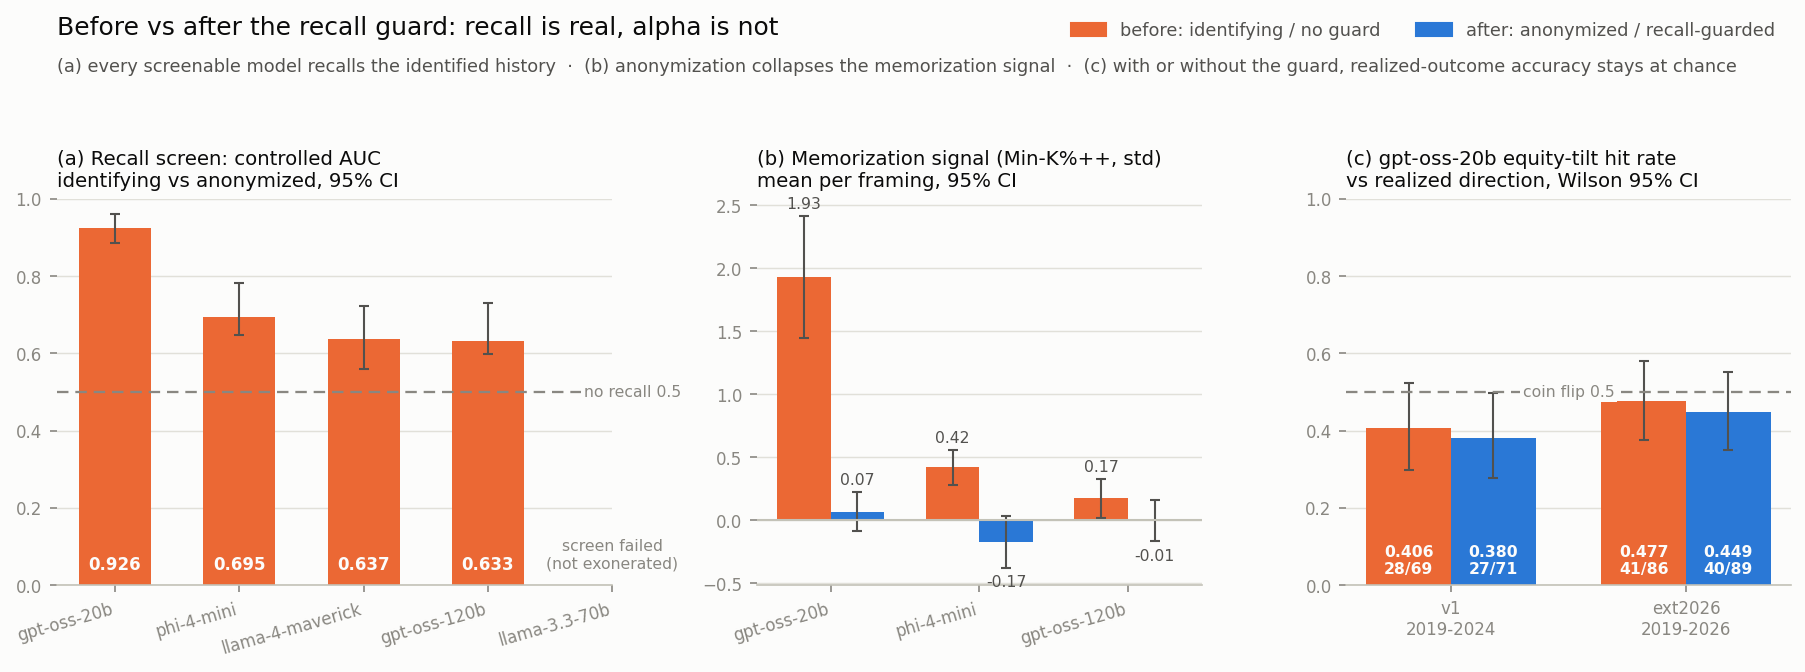

In [5]:
fig, (axA, axB, axC) = plt.subplots(
    1, 3, figsize=(12.5, 4.6), dpi=150, gridspec_kw={"width_ratios": [1.25, 1, 1], "wspace": 0.3})
fig.patch.set_facecolor(SURFACE)
for a in (axA, axB, axC):
    a.set_facecolor(SURFACE)
    a.grid(axis="y", color=GRID, lw=0.7)
    a.set_axisbelow(True)
    a.tick_params(colors=MUTED, labelsize=8)
    for s in ("top", "right", "left"):
        a.spines[s].set_visible(False)
    a.spines["bottom"].set_color(BASELINE)
mask = dict(facecolor=SURFACE, edgecolor="none", pad=1.2)

# (a) controlled AUC per model
xs = np.arange(len(auc_df))
ok = auc_df["controlled_auc"].notna()
axA.bar(xs[ok], auc_df.loc[ok, "controlled_auc"], 0.58, color=ORANGE)
axA.errorbar(xs[ok], auc_df.loc[ok, "controlled_auc"],
             yerr=[auc_df.loc[ok, "controlled_auc"] - auc_df.loc[ok, "ci_low"],
                   auc_df.loc[ok, "ci_high"] - auc_df.loc[ok, "controlled_auc"]],
             fmt="none", ecolor=INK2, elinewidth=1, capsize=2.5)
for x, v in zip(xs[ok], auc_df.loc[ok, "controlled_auc"]):
    axA.text(x, 0.04, f"{v:.3f}", ha="center", color=SURFACE, fontsize=8, fontweight="bold")
for x in xs[~ok]:
    axA.text(x, 0.045, "screen failed\n(not exonerated)", ha="center", color=MUTED, fontsize=7.5)
axA.axhline(0.5, color=MUTED, lw=1.1, ls=(0, (5, 3)))
axA.text(len(auc_df) - 0.45, 0.5, "no recall 0.5", color=MUTED, fontsize=7.5,
         va="center", ha="right", bbox=mask)
axA.set_xticks(xs, auc_df["model"], rotation=16, ha="right")
axA.set_ylim(0, 1)
axA.set_title("(a) Recall screen: controlled AUC\nidentifying vs anonymized, 95% CI",
              color=INK, fontsize=9.5, loc="left")

# (b) memorization signal before/after anonymization
mods = mia_df["model"].unique()
xs = np.arange(len(mods))
w = 0.36
for off, arm, col in [(-w / 2, "identifying", ORANGE), (w / 2, "anonymized", BLUE)]:
    g = mia_df[mia_df["arm"] == arm].set_index("model").loc[mods]
    axB.bar(xs + off, g["mean_std_min_k_pp"], w, color=col)
    axB.errorbar(xs + off, g["mean_std_min_k_pp"], yerr=g["ci95"],
                 fmt="none", ecolor=INK2, elinewidth=1, capsize=2.5)
    for x, v, ci in zip(xs + off, g["mean_std_min_k_pp"], g["ci95"]):
        y = v + ci + 0.06 if v >= 0 else v - ci - 0.15
        axB.text(x, y, f"{v:.2f}", ha="center", color=INK2, fontsize=7.5)
axB.axhline(0, color=BASELINE, lw=1)
axB.set_xticks(xs, mods, rotation=16, ha="right")
axB.set_title("(b) Memorization signal (Min-K%++, std)\nmean per framing, 95% CI",
              color=INK, fontsize=9.5, loc="left")

# (c) gpt-oss-20b directional hit rate vs realized outcome
wins = ["v1 (2019-2024)", "ext2026 (2019-2026)"]
xs = np.arange(len(wins))
for off, line, col in [(-w / 2, "before (no guard)", ORANGE), (w / 2, "after (guarded)", BLUE)]:
    g = hit_df[hit_df["line"] == line].set_index("window").loc[wins]
    axC.bar(xs + off, g["hit_rate"], w, color=col)
    axC.errorbar(xs + off, g["hit_rate"],
                 yerr=[g["hit_rate"] - g["wilson_lo"], g["wilson_hi"] - g["hit_rate"]],
                 fmt="none", ecolor=INK2, elinewidth=1, capsize=2.5)
    for x, v, h in zip(xs + off, g["hit_rate"], g["hits"]):
        axC.text(x, 0.03, f"{v:.3f}\n{h}", ha="center", color=SURFACE,
                 fontsize=7.5, fontweight="bold")
axC.axhline(0.5, color=MUTED, lw=1.1, ls=(0, (5, 3)))
axC.text(0.5, 0.5, "coin flip 0.5", color=MUTED, fontsize=7.5, va="center",
         ha="center", bbox=mask)
axC.set_xticks(xs, ["v1\n2019-2024", "ext2026\n2019-2026"])
axC.set_ylim(0, 1)
axC.set_title("(c) gpt-oss-20b equity-tilt hit rate\nvs realized direction, Wilson 95% CI",
              color=INK, fontsize=9.5, loc="left")

handles = [plt.Rectangle((0, 0), 1, 1, color=ORANGE), plt.Rectangle((0, 0), 1, 1, color=BLUE)]
fig.legend(handles, ["before: identifying / no guard", "after: anonymized / recall-guarded"],
           loc="upper right", bbox_to_anchor=(0.99, 1.0), ncol=2, frameon=False,
           fontsize=8.5, labelcolor=INK2)
fig.text(0.065, 0.985, "Before vs after the recall guard: recall is real, alpha is not",
         color=INK, fontsize=12, va="top")
fig.text(0.065, 0.925,
         "(a) every screenable model recalls the identified history  ·  "
         "(b) anonymization collapses the memorization signal  ·  "
         "(c) with or without the guard, realized-outcome accuracy stays at chance",
         color=INK2, fontsize=8.5, va="top")
fig.subplots_adjust(top=0.72, bottom=0.16, left=0.065, right=0.99)
fig.savefig(DATA / "appendix_b_before_after_guard.png", bbox_inches="tight", facecolor=SURFACE)
plt.show()

## 6. Reading — before/after bars

Panel (a): the screen certifies that recall is present in every screenable candidate,
gpt-oss-20b most strongly (controlled AUC 0.926, permutation p = 0.002), so no model may
be assumed clean; llama-3.3-70b's failed screen means *not exonerated*, not passed.
Panel (b): the mechanism — the Min-K%++ memorization signal is elevated exactly when the
prompt identifies the history (dates + tickers + raw levels) and collapses to ≈ 0 under
the guard's anonymized rendering, for all three models with row-level evidence.
Panel (c): the consequence — for the deployed model, the unguarded (non-PIT diagnostic)
and guarded (PIT deployable) lines both sit at coin-flip accuracy against realized
next-month direction (all four Wilson intervals contain 0.5; exact McNemar on paired
dates cannot distinguish them). Memorized history is demonstrably present (a, b) but
buys no forward-looking alpha (c) — the guard removes the recall channel at zero cost to
predictive skill, because there was none. Chart exported to
`data/appendix_b_before_after_guard.png`.